---
title: Multivariate > K-Clustering
jupyter: python3
---

<div class="alert alert-info">Create segments using K-clustering: group respondents that are similar within and different across clusters.</div>

In [1]:
import polars as pl
import pyrsm as rsm

In [2]:
## setup pyrsm for autoreload
%reload_ext autoreload
%autoreload 2
%aimport pyrsm

## What K-Clustering Does

The goal of Cluster Analysis is to group respondents (e.g., consumers) into segments based on needs, benefits, and/or behaviors. The tool tries to achieve this goal by looking for respondents that are similar, putting them together in a cluster or segment, and separating them from other, dissimilar, respondents. The researcher compares the segments and provides a descriptive label for each.

After determining the appropriate number of clusters to extract using Hierarchical cluster analysis we use K-clustering to create the final segments. The main advantage of this algorithm is its flexibility and robustness in finding the most appropriate grouping of respondents. For marketing and business data we often use Hierarchical cluster analysis to select the number of segments and K-clustering to create the final segments.

## How K-Clustering Differs from Hierarchical Clustering

Hierarchical clustering builds a tree (dendrogram) by successively merging the two most similar observations or groups. It never reconsiders a merge once it is made, so an observation that joined a group early can never be moved later. That makes the dendrogram and scree/change plots ideal for *deciding how many clusters* to extract, but the assignments themselves can be sub-optimal.

K-clustering takes the desired number of clusters, `nr_clus`, as an input and then iteratively re-assigns every observation to the nearest cluster center and recomputes the centers until the solution stabilizes. Because observations can move between clusters across iterations, K-clustering typically produces a tighter, more robust final grouping. The common workflow is therefore: use hierarchical clustering to pick the number of segments, then use K-clustering to create the final segments.

By default `pyrsm` initializes the K-clustering algorithm from the centers produced by a hierarchical cluster analysis (`hc_init=True`). For datasets with relatively few observations this deterministic starting point avoids the randomness of choosing initial centers at random and makes the results reproducible.

## Example: Shopping Attitudes (K-means)

The `shopping` dataset records six attitude items (`v1`-`v6`) for 20 respondents. We will look for groups of shoppers with similar attitudes. To apply K-clustering we select `kmeans` as the algorithm, variables `v1` through `v6`, and the number of clusters. Because the data has relatively few observations we use Hierarchical Cluster Analysis (HC) to provide the initial cluster centers (the default).

In [3]:
shopping = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/shopping.parquet"
)
shopping.head()

id,v1,v2,v3,v4,v5,v6
i32,i32,i32,i32,i32,i32,i32
1,6,4,7,3,2,3
2,2,3,1,4,5,4
3,7,2,6,4,1,3
4,4,6,4,5,3,6
5,1,3,2,2,6,4


### Choosing the Number of Clusters

K-clustering does not pick the number of segments for you; you must supply `nr_clus`. The standard approach is to first run a hierarchical cluster analysis and inspect the scree and change plots: a large jump in within-cluster heterogeneity as you go from `k` to `k-1` clusters suggests that `k` is a good number to extract.

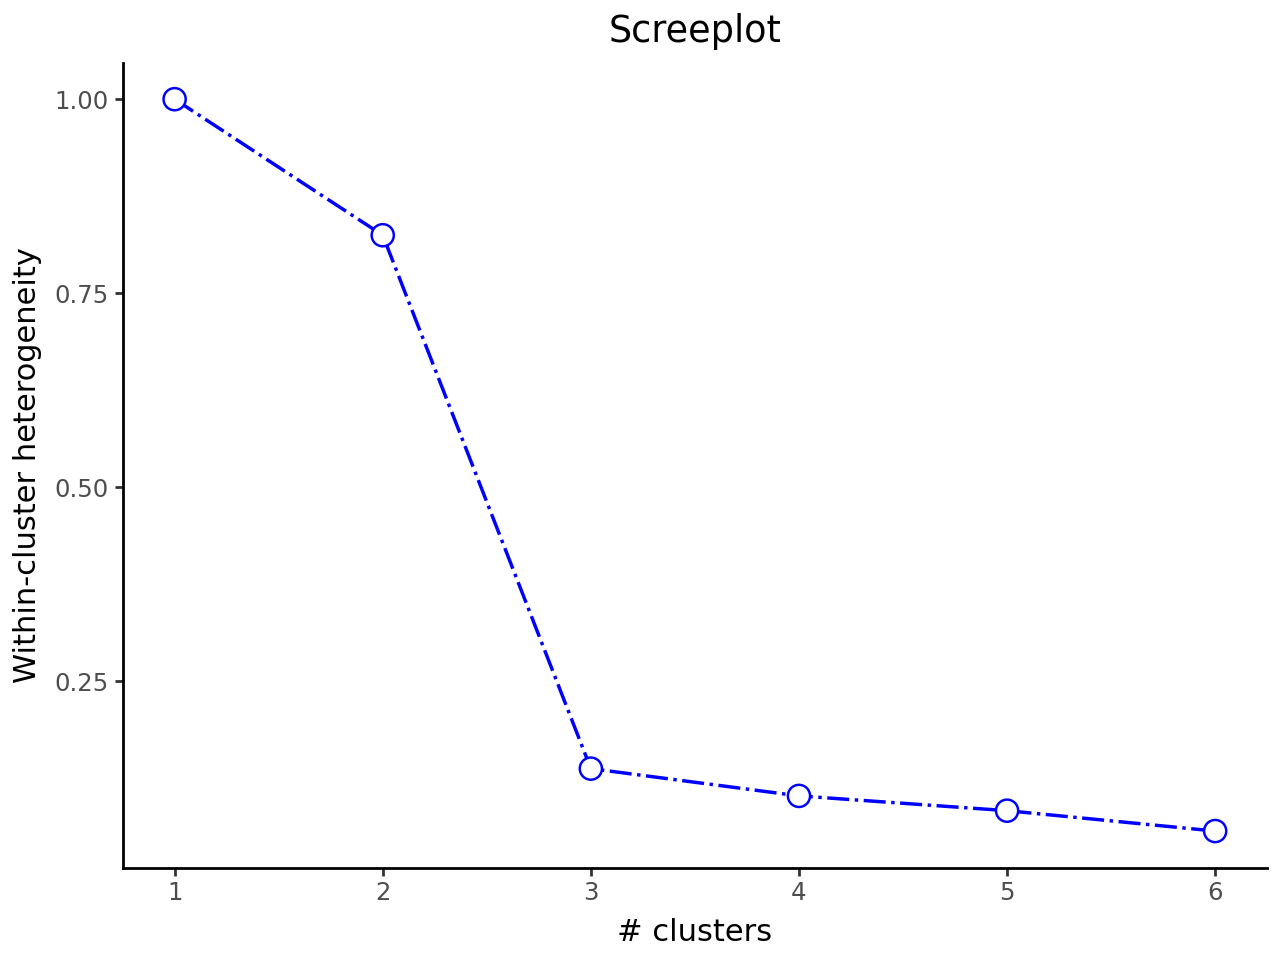

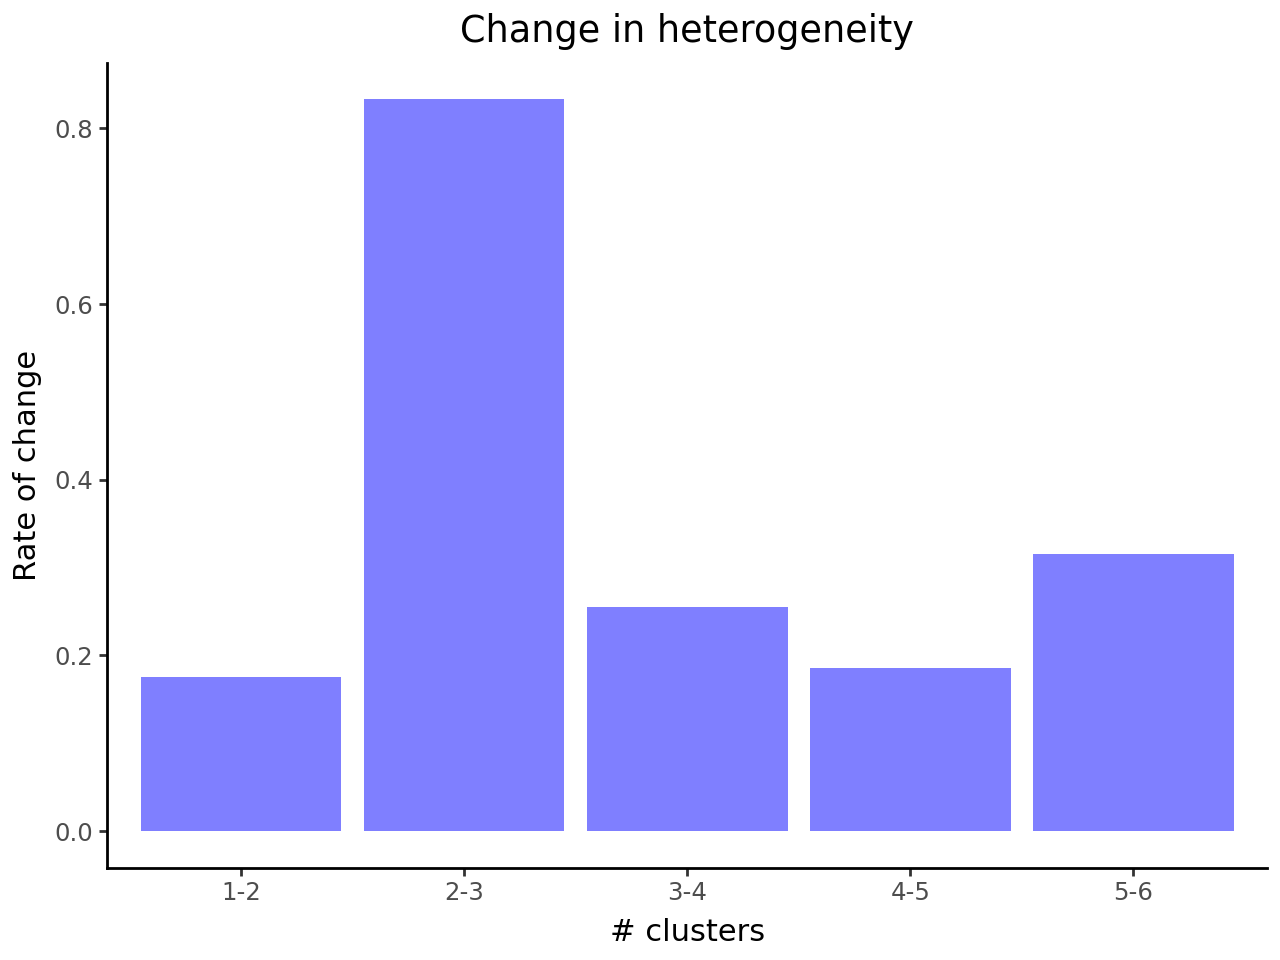

In [4]:
hc = rsm.multivariate.hclus({"shopping": shopping}, "v1:v6")
hc.plot(plots=["scree", "change"])

Below we extract 3 clusters with K-means, initialized from the hierarchical-clustering centers.

In [5]:
km = rsm.multivariate.kclus({"shopping": shopping}, vars="v1:v6", nr_clus=3)
km.summary()

K-means cluster analysis
Data         : shopping
Variables    : v1, v2, v3, v4, v5, v6
Clustering by: K-means
HC method    : ward.D
HC distance  : sq.euclidian
Standardize  : True
Observations : 20
Generated    : 3 clusters of sizes 8 | 6 | 6

Cluster means:
shape: (3, 7)
┌───────────┬──────────┬──────────┬──────────┬───────┬───────┬──────────┐
│ Cluster   ┆ v1       ┆ v2       ┆ v3       ┆ v4    ┆ v5    ┆ v6       │
│ ---       ┆ ---      ┆ ---      ┆ ---      ┆ ---   ┆ ---   ┆ ---      │
│ str       ┆ f64      ┆ f64      ┆ f64      ┆ f64   ┆ f64   ┆ f64      │
╞═══════════╪══════════╪══════════╪══════════╪═══════╪═══════╪══════════╡
│ Cluster 1 ┆ 5.75     ┆ 3.625    ┆ 6.0      ┆ 3.125 ┆ 1.875 ┆ 3.875    │
│ Cluster 2 ┆ 1.666667 ┆ 3.0      ┆ 1.833333 ┆ 3.5   ┆ 5.5   ┆ 3.333333 │
│ Cluster 3 ┆ 3.5      ┆ 5.833333 ┆ 3.333333 ┆ 6.0   ┆ 3.5   ┆ 6.0      │
└───────────┴──────────┴──────────┴──────────┴───────┴───────┴──────────┘

Percentage of within-cluster heterogeneity accounted for by 

### Reading the Cluster Means

In the summary output we use the `Cluster means` table to describe the individuals assigned to a segment. Each number in the table shows the average score on a variable for people in that segment. We are looking for either very high or very low mean values to help distinguish segments because we want to establish how one segment differs from the others. If there are no substantial differences in the mean value of a variable across different segments, that variable is not very useful for interpretation. By highlighting the variables that most clearly distinguish the different segments we can generate a name or label that describes consumers in each segment and illustrates how the segments differ from one another.

The cluster means are also available directly as an attribute.

In [6]:
km.clus_means

v1,v2,v3,v4,v5,v6
f64,f64,f64,f64,f64,f64
5.75,3.625,6.0,3.125,1.875,3.875
1.666667,3.0,1.833333,3.5,5.5,3.333333
3.5,5.833333,3.333333,6.0,3.5,6.0


### Reading Heterogeneity

The summary also reports how the total heterogeneity in the data is split into a within-cluster part and a between-cluster part. The within-cluster percentages show how much of the (remaining) within-cluster heterogeneity each cluster contributes. The headline number — the share of total heterogeneity accounted for *between* clusters — summarizes how well separated the segments are: higher is better. A solution that explains a large fraction of the variation between clusters is doing a good job of separating dissimilar respondents.

The underlying quantities are available as attributes for further analysis.

In [7]:
print("Cluster sizes:", km.sizes)
print("Within-cluster sum of squares per cluster:", km.withinss)
print("Total within-cluster SS:", km.tot_withinss)
print("Between-cluster SS:", km.betweenss)
print("Total SS:", km.totss)
print(f"Between / Total = {km.betweenss / km.totss:.2%}")

Cluster sizes: [8 6 6]
Within-cluster sum of squares per cluster: [11.97688222  7.72141785 10.01701888]
Total within-cluster SS: 29.71531894374396
Between-cluster SS: 84.28468105625603
Total SS: 114.0
Between / Total = 73.93%


## Visualizing the Clusters

It can be useful to visualize how well the segments are separated by plotting the data for each segment and variable.

The bar plot shows the cluster means for each variable with `mean +/- margin-of-error` bars, making it easy to spot which variables most clearly distinguish the segments.

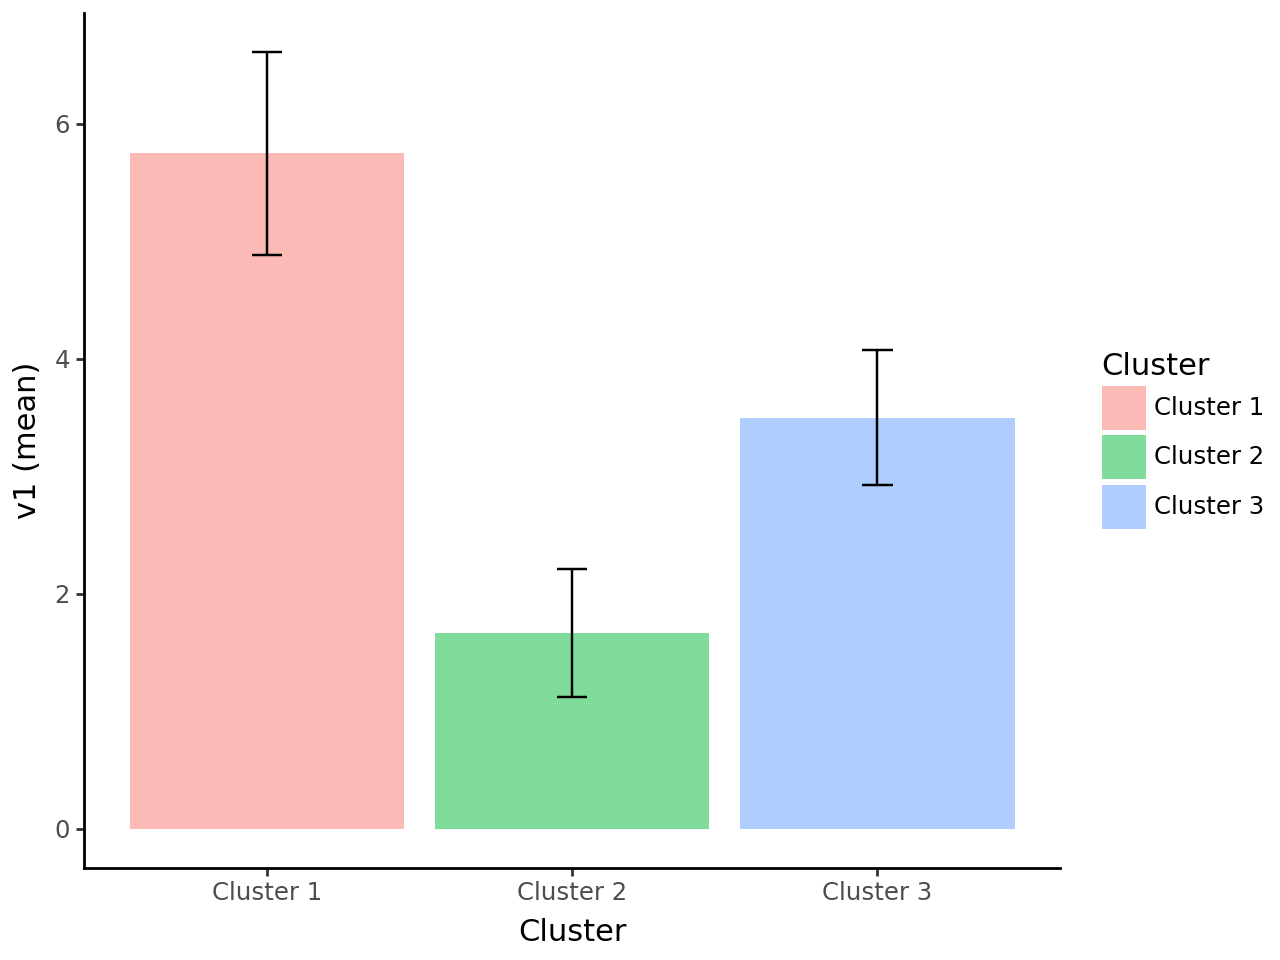

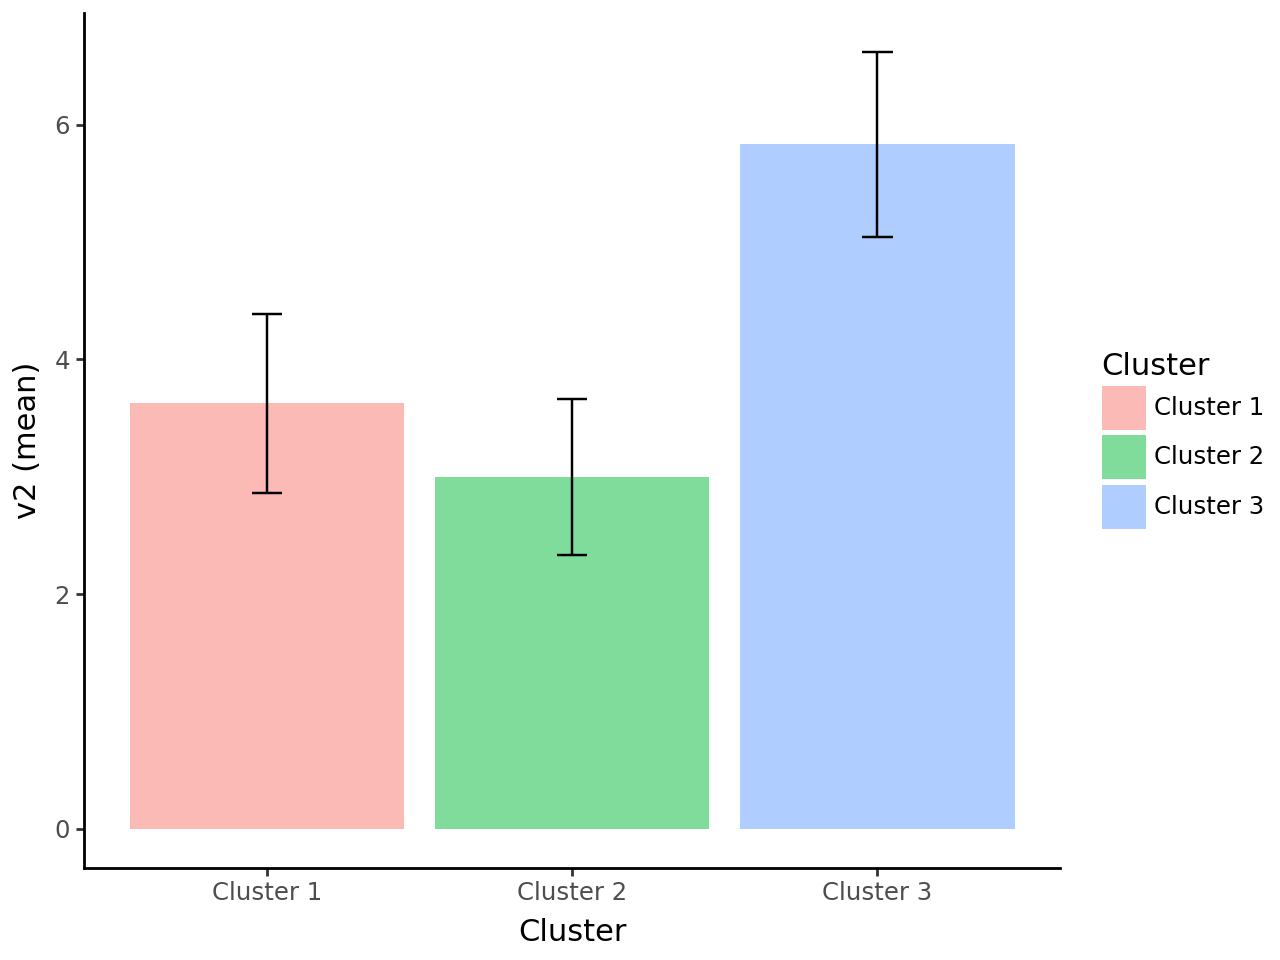

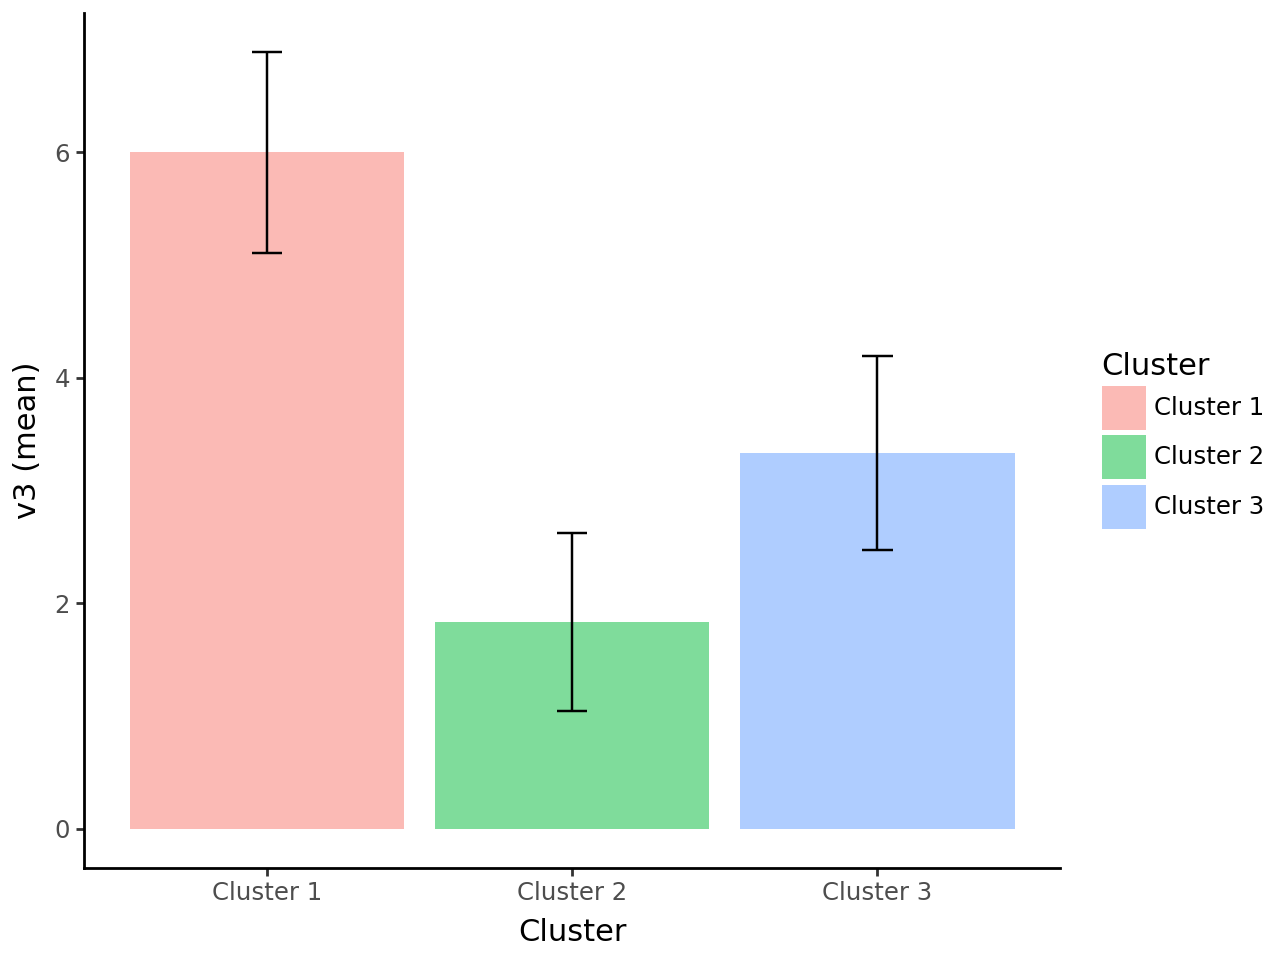

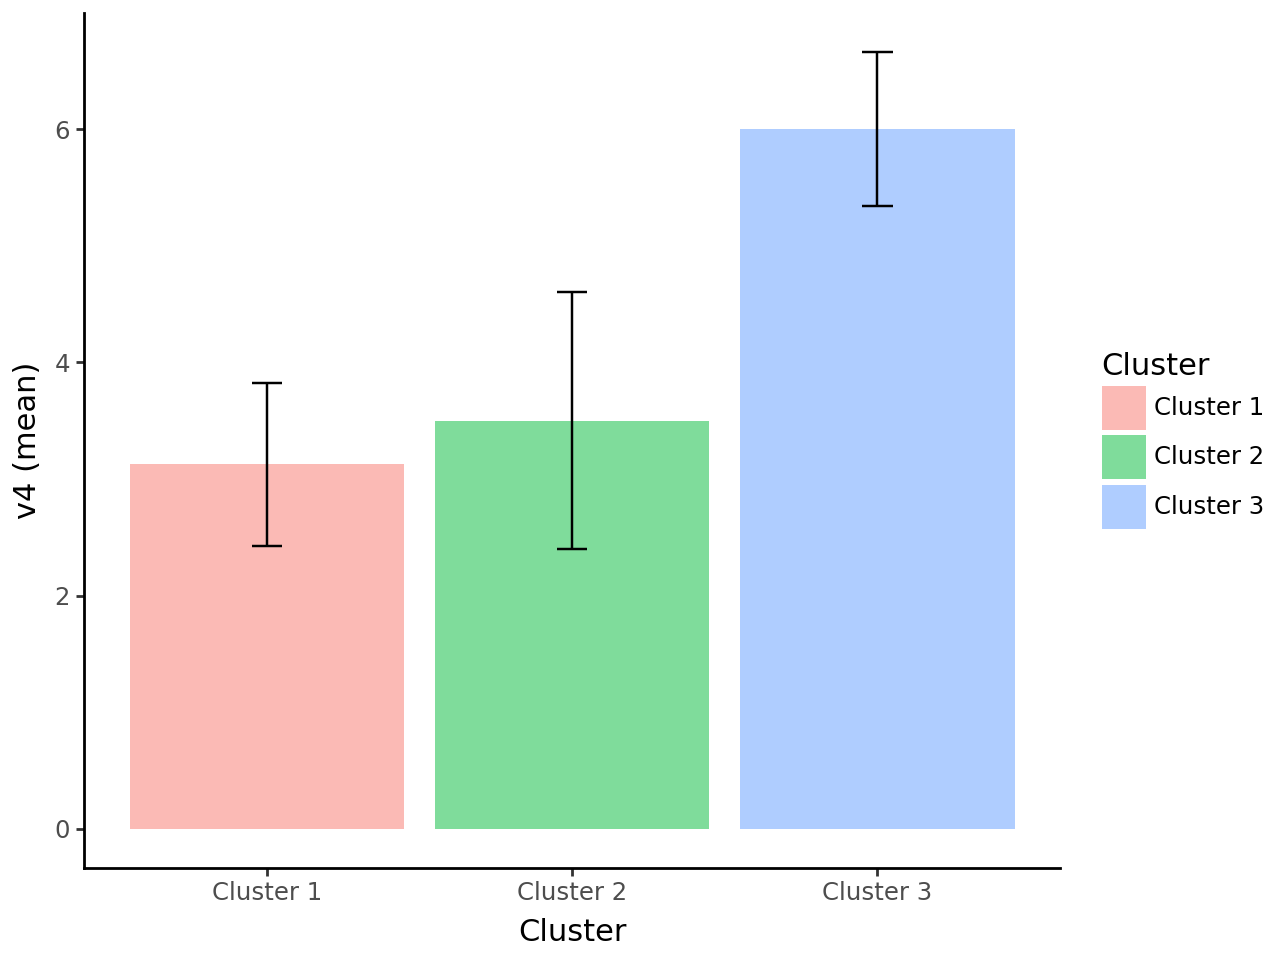

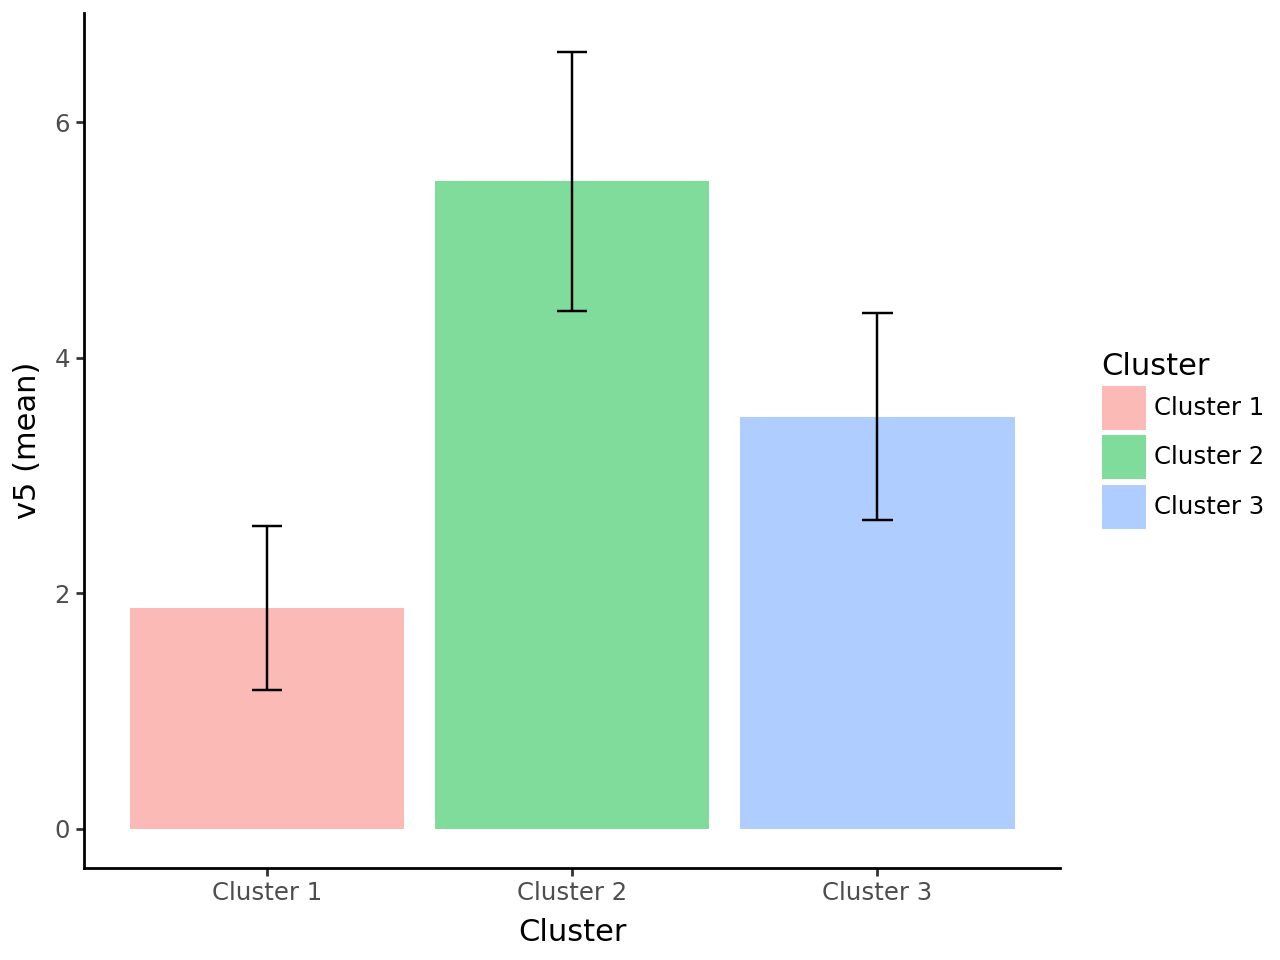

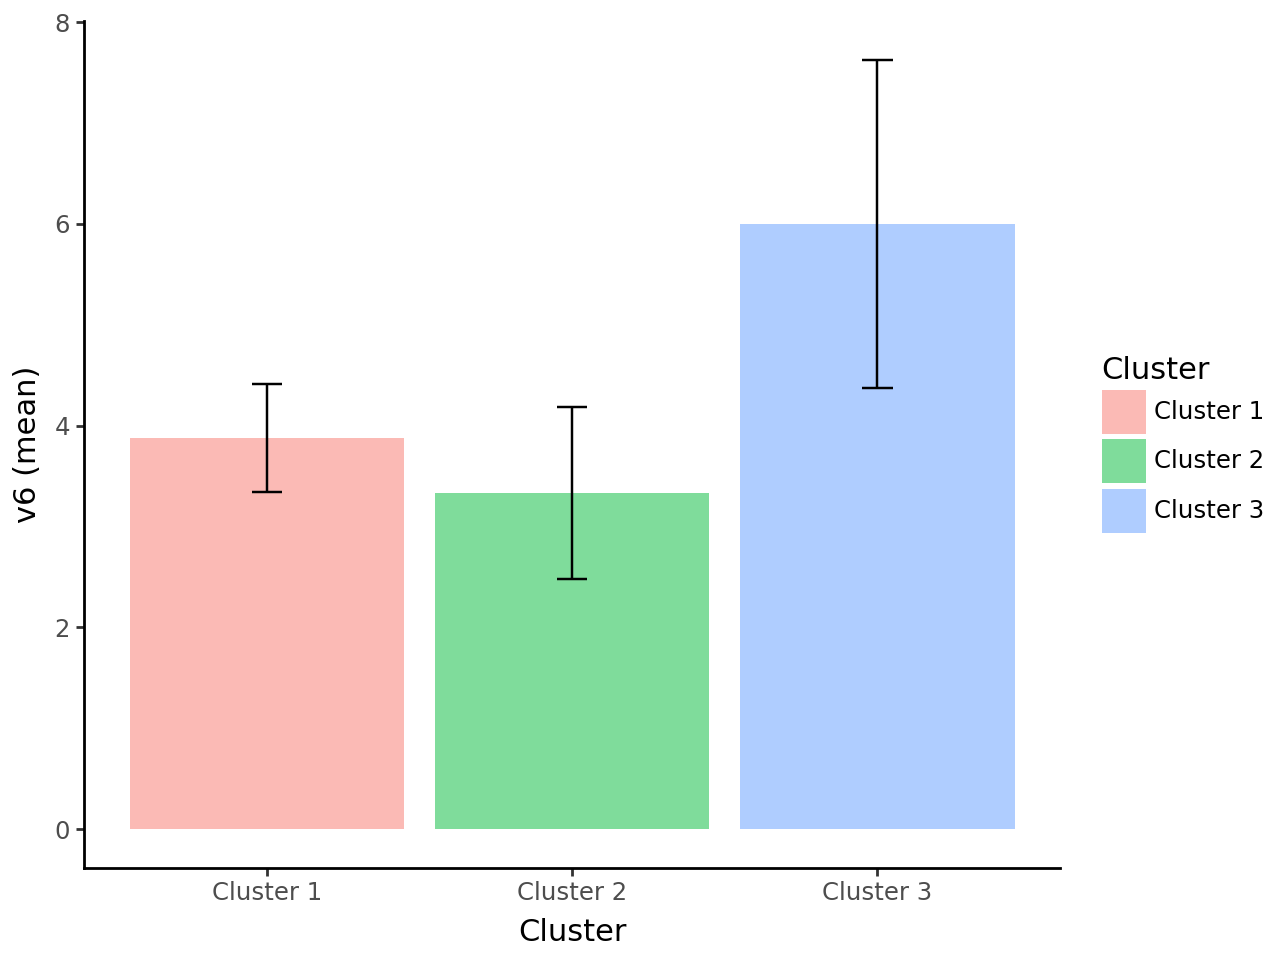

In [8]:
km.plot(plots="bar")

Density plots show the full distribution of each variable within each cluster. Where the densities for the different clusters are nicely separated, that variable distinguishes the segments well. Where the densities overlap heavily, the variable does little to differentiate the segments.

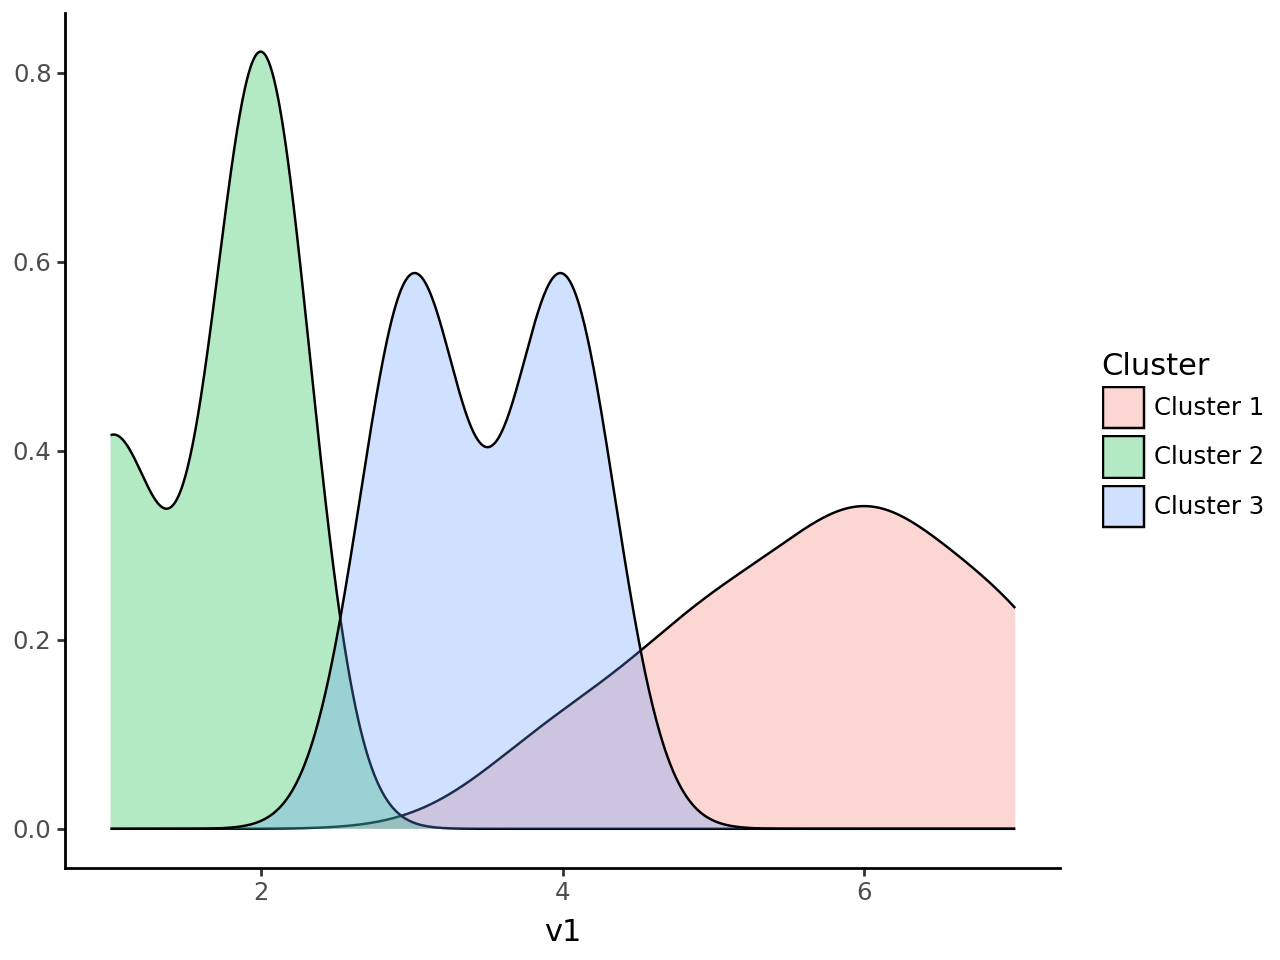

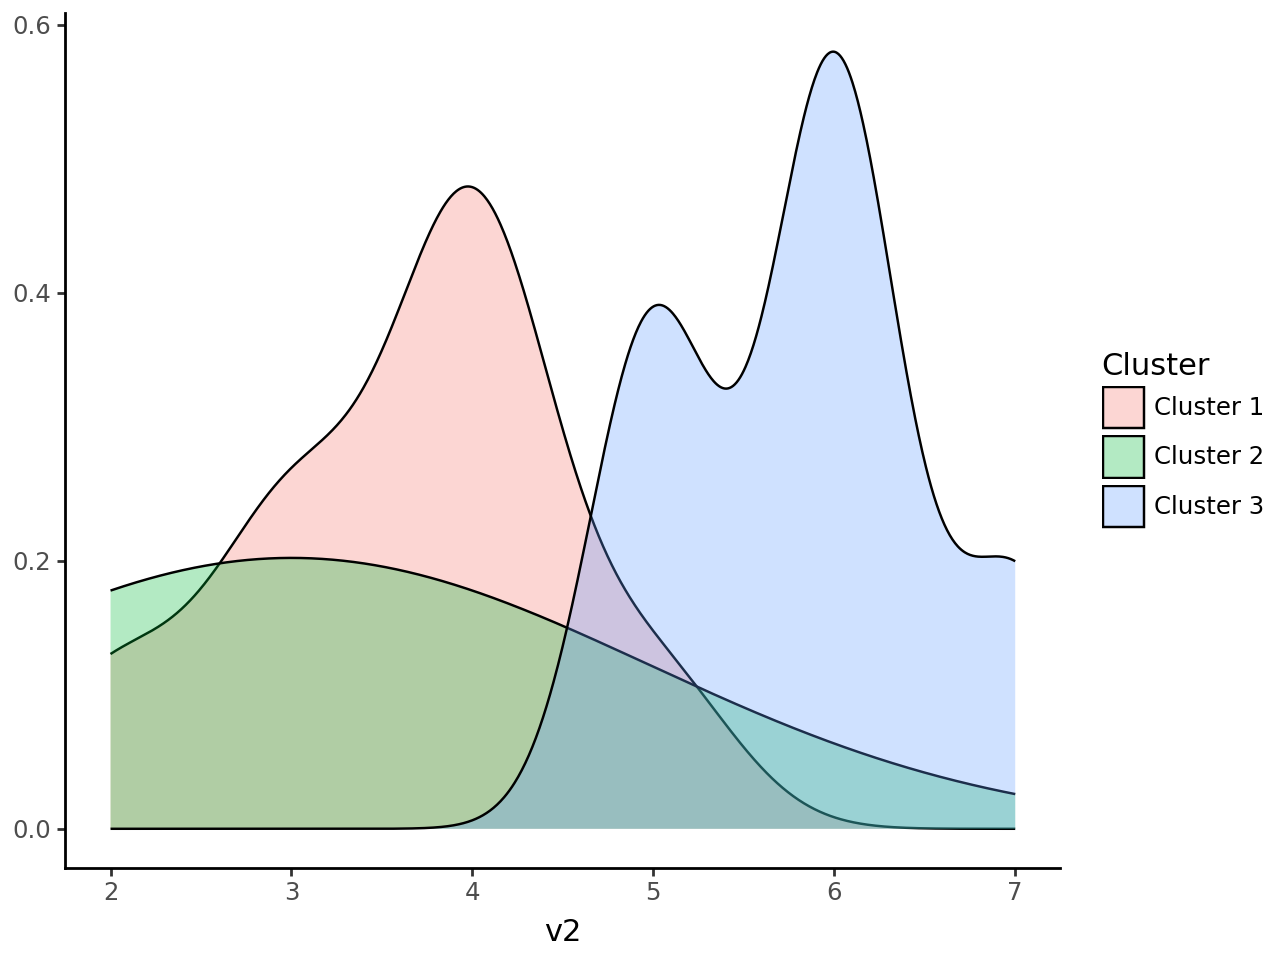

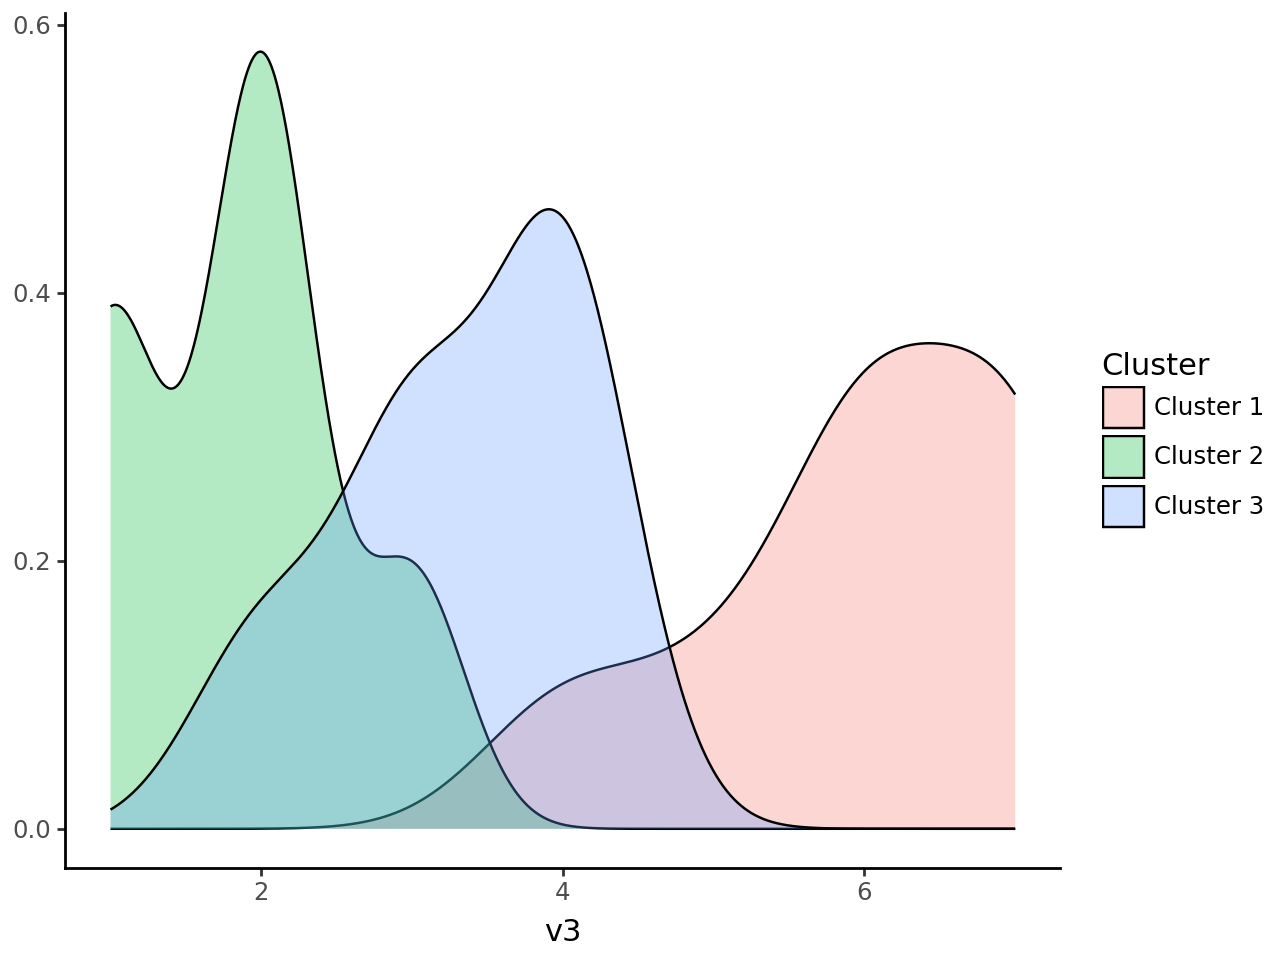

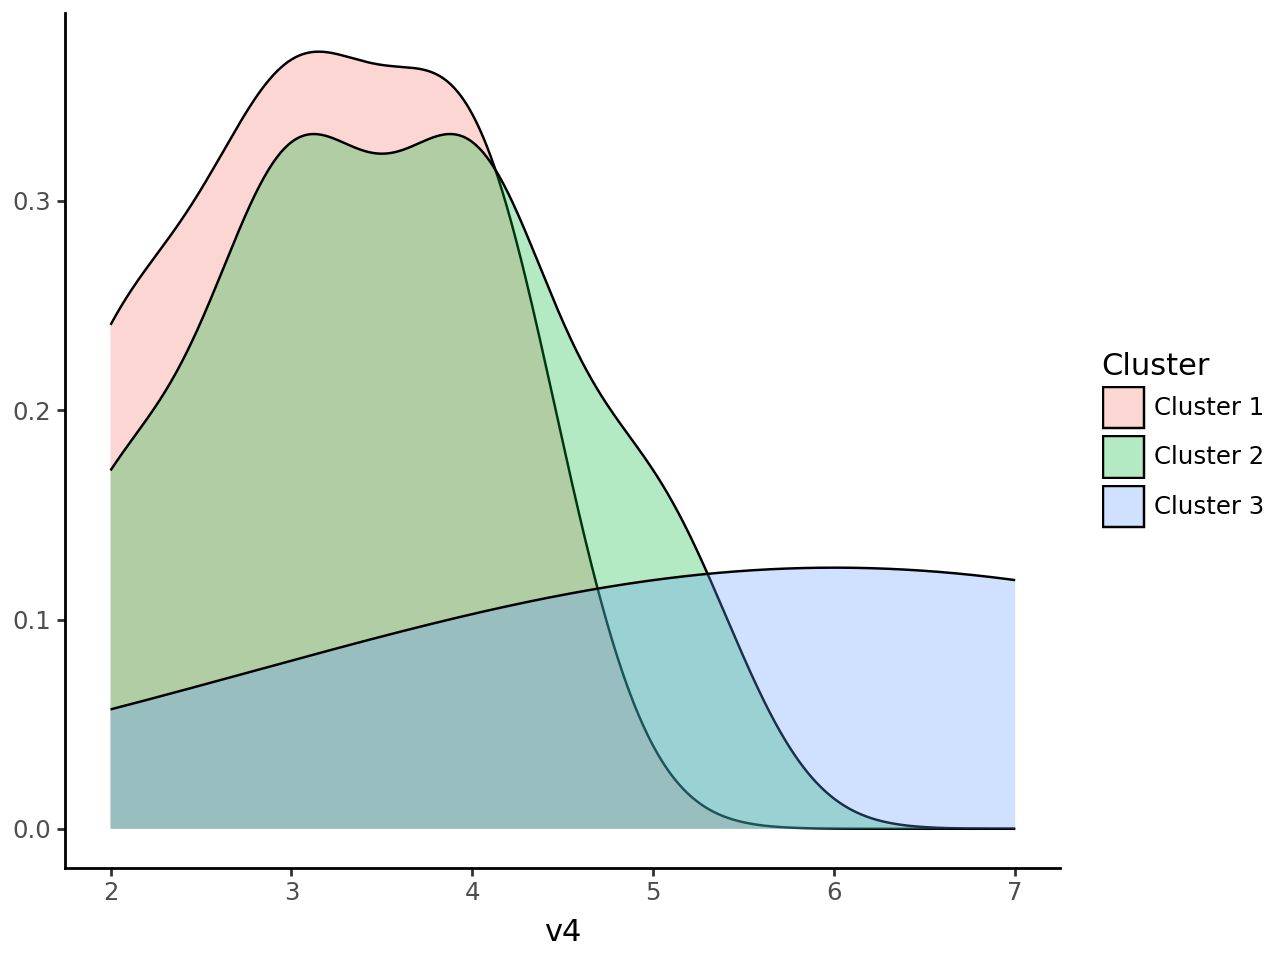

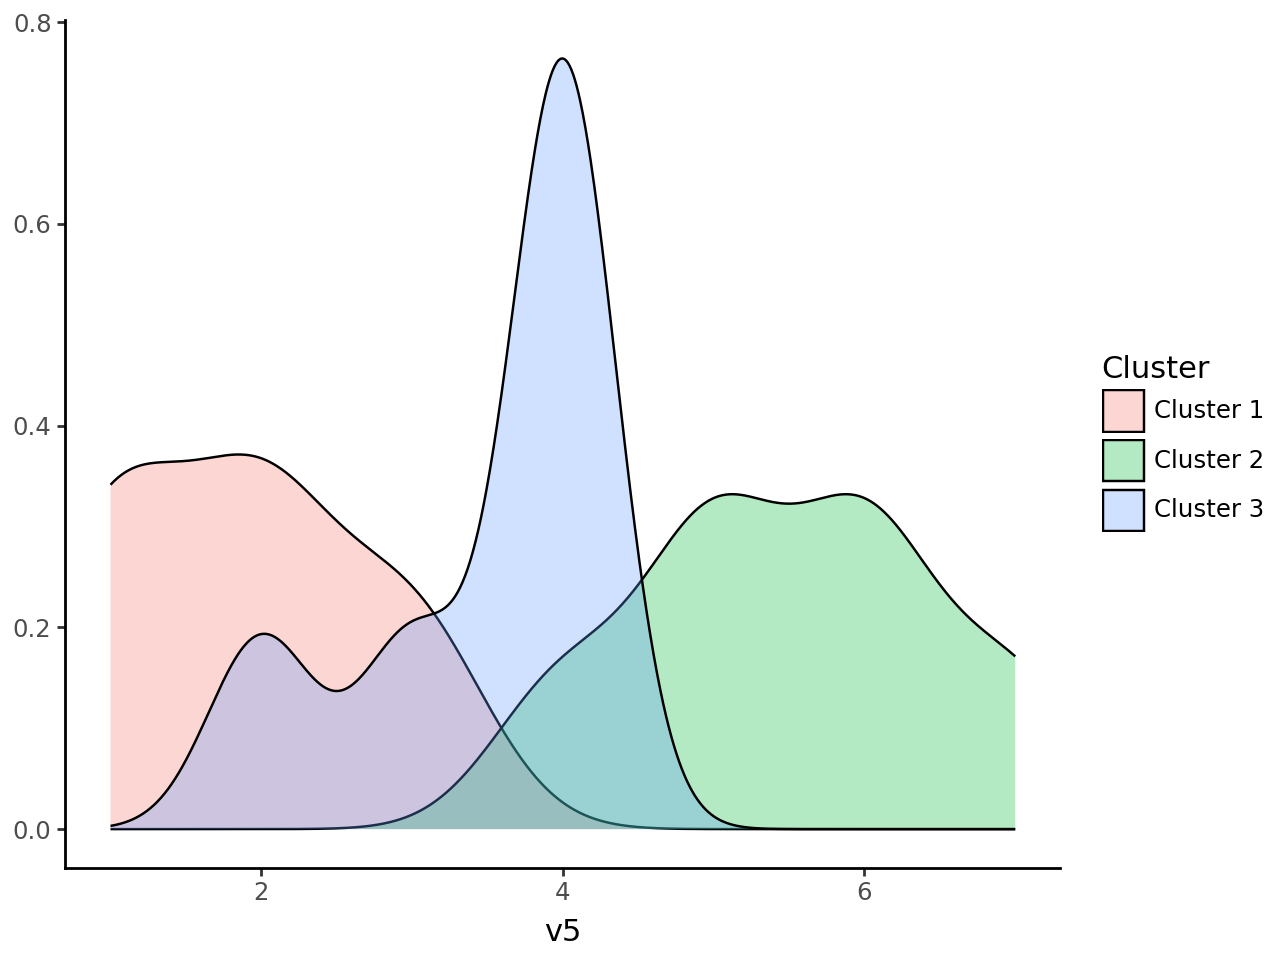

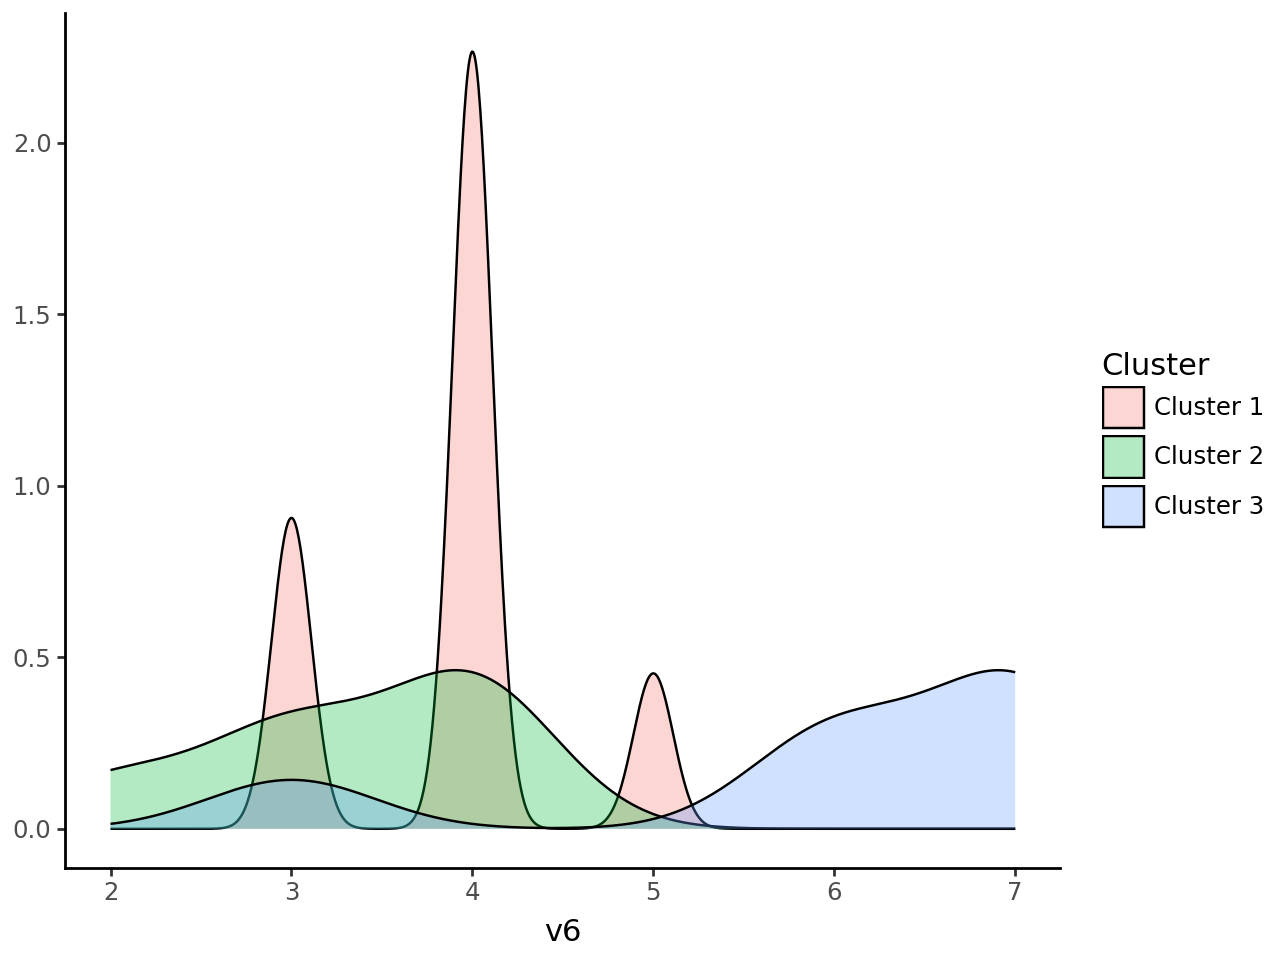

In [9]:
km.plot(plots="density")

A jittered scatter plot lets us see the individual observations colored by cluster assignment, which helps reveal how tight and well-separated the segments are.

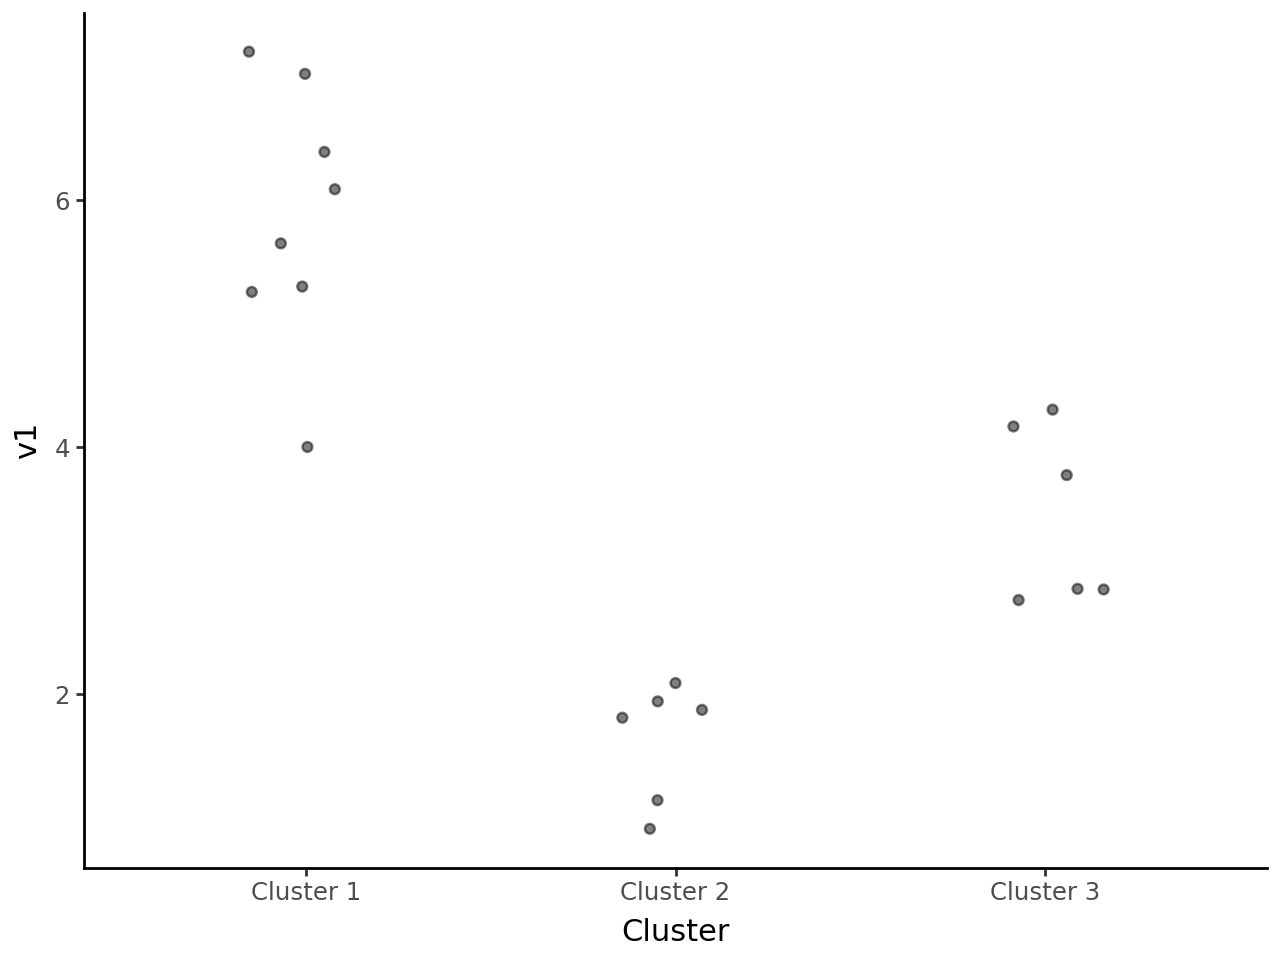

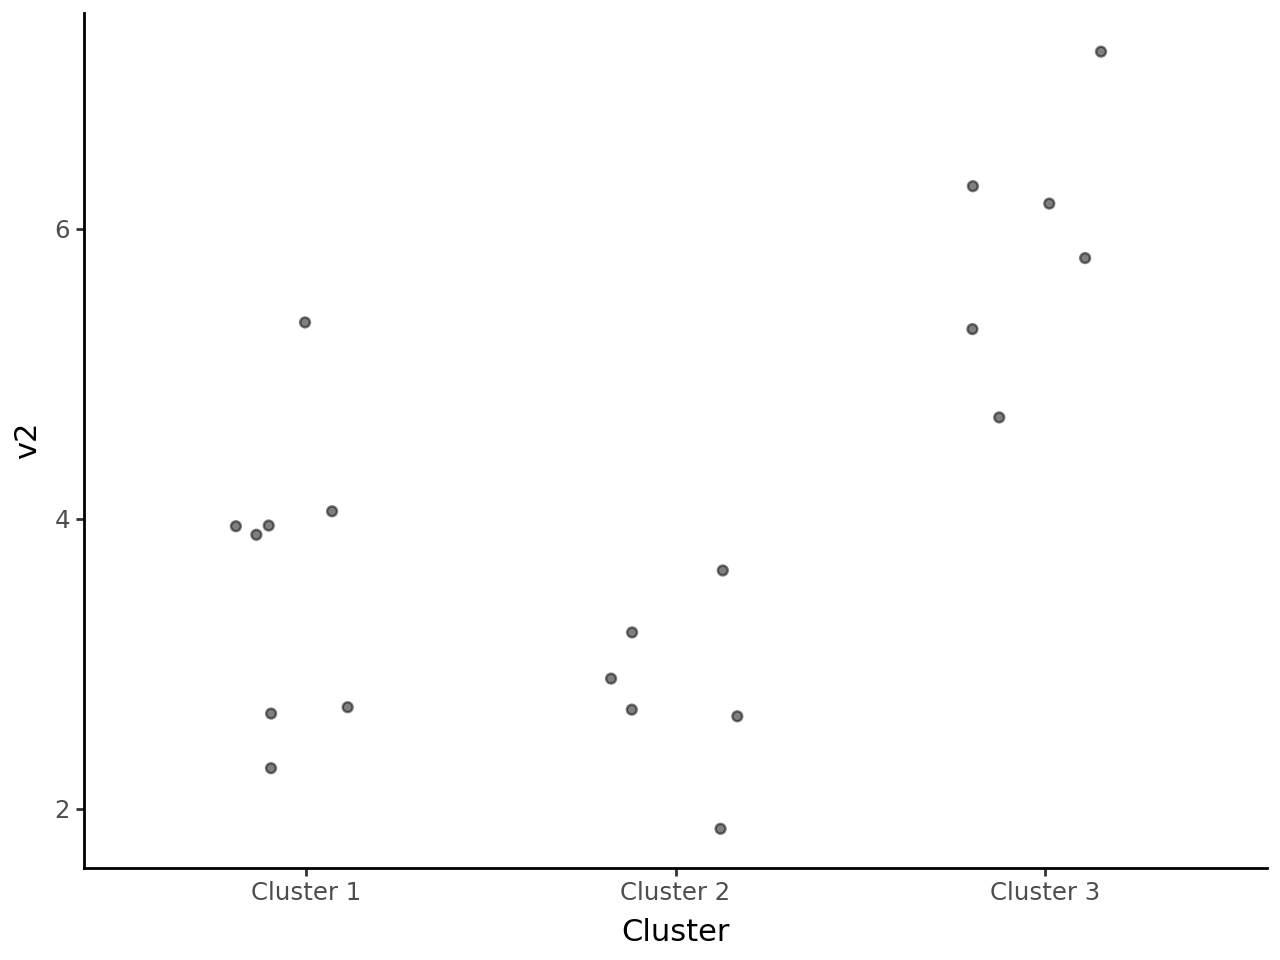

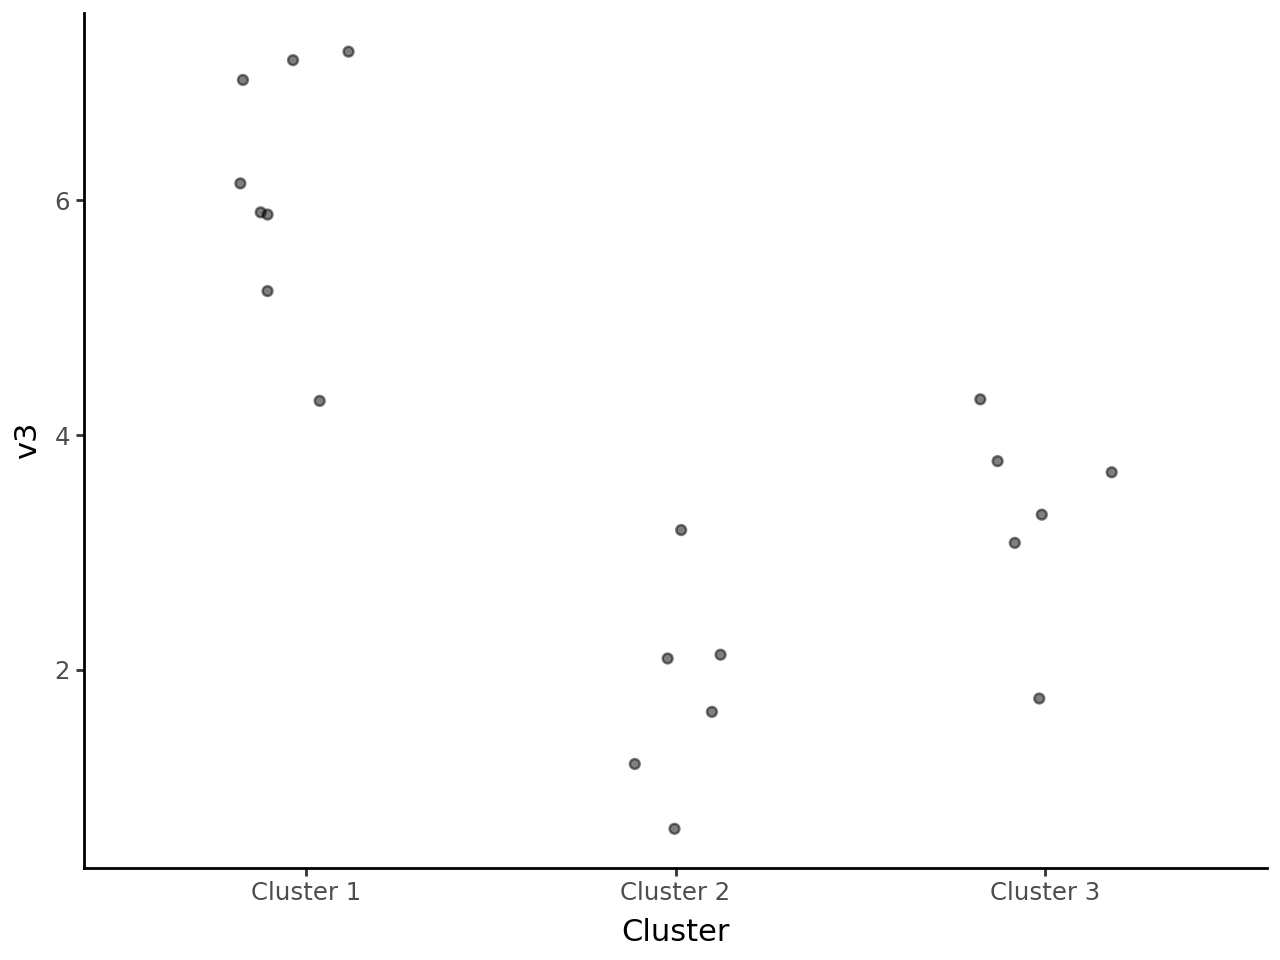

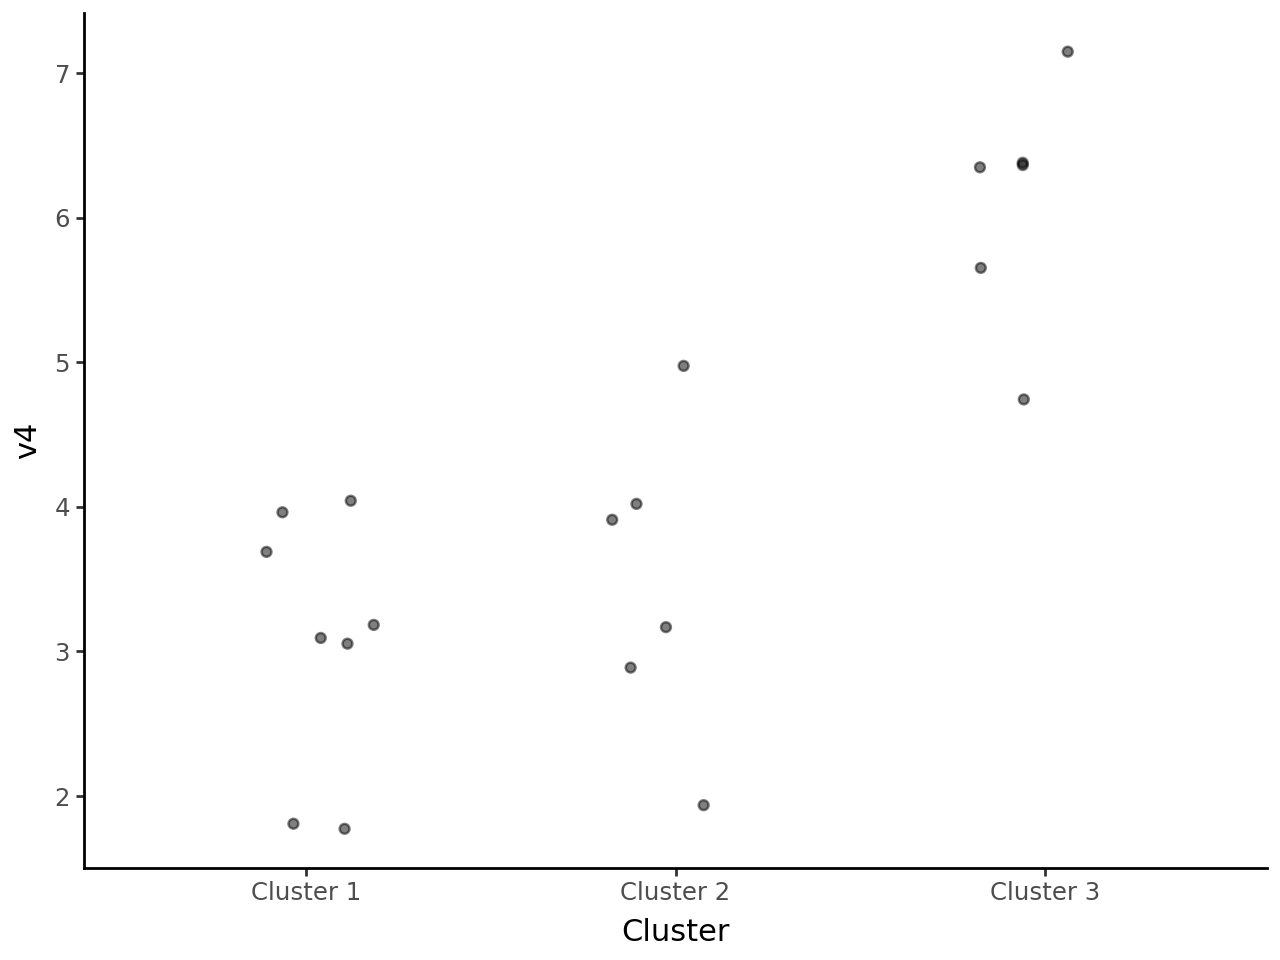

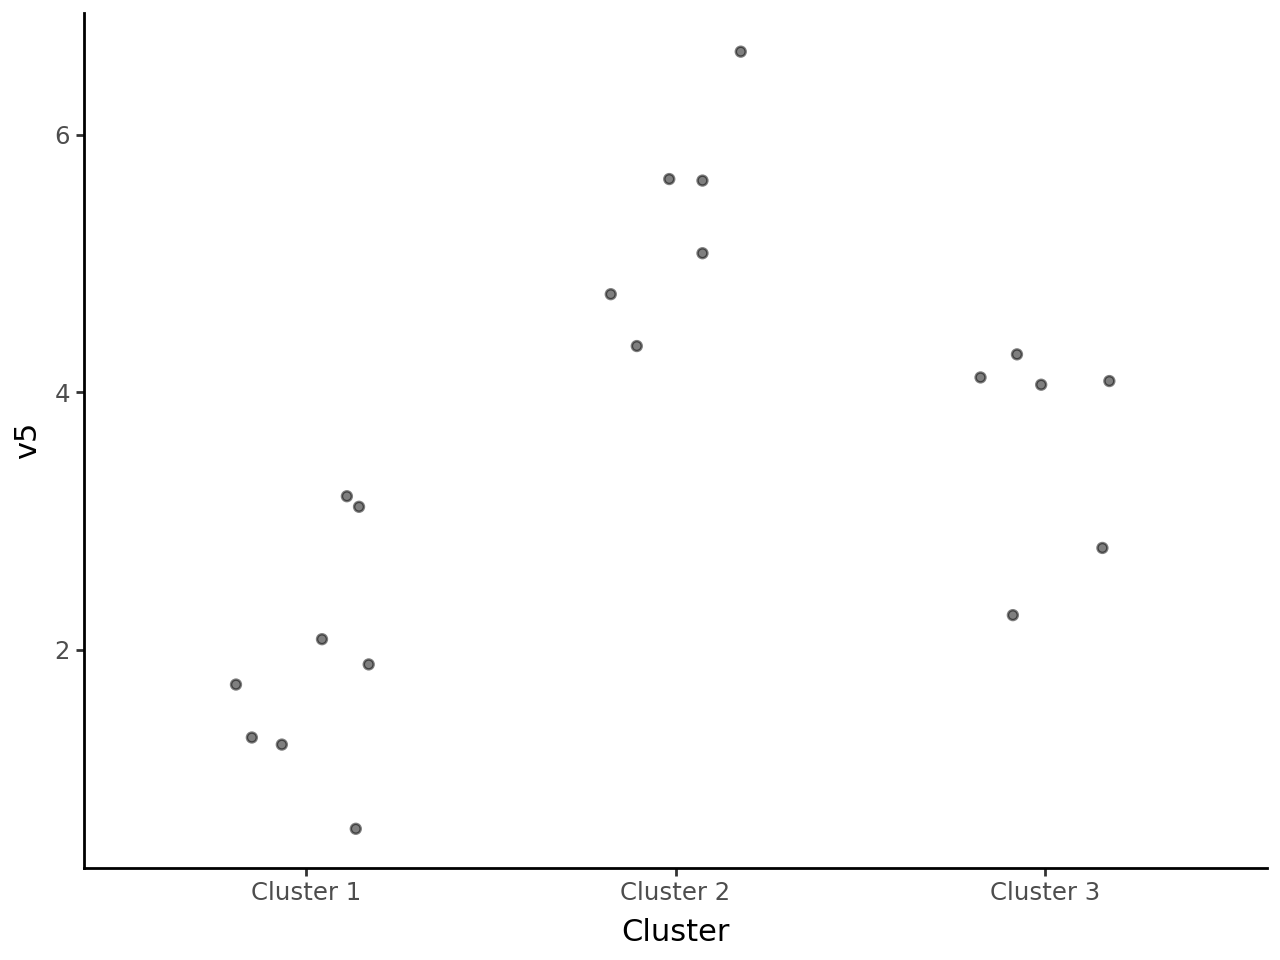

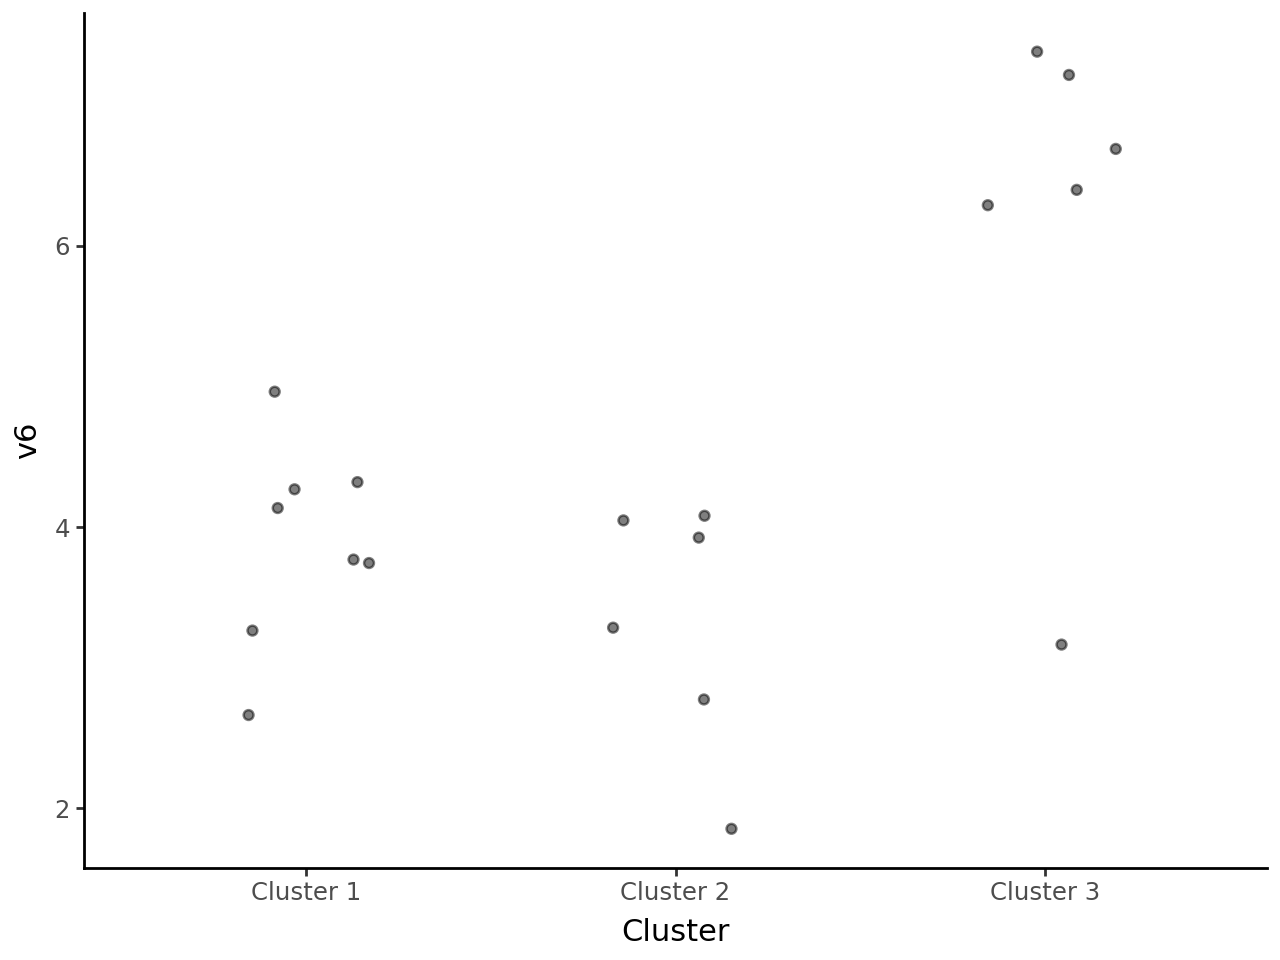

In [10]:
km.plot(plots="scatter")

By reviewing the cluster means table together with these plots we can derive descriptive labels for each segment, highlighting the variables on which a segment scores notably high or low.

## Storing Cluster Membership

Once we are happy with the segments we can create a segment (or cluster) membership variable with `store`. A new column is added to the data showing which cluster each respondent was assigned to (i.e., cluster membership). The column is named `kclus<nr_clus>` (here `kclus3`).

In [11]:
clustered = km.store(shopping)
clustered.head()

id,v1,v2,v3,v4,v5,v6,kclus3
i32,i32,i32,i32,i32,i32,i32,cat
1,6,4,7,3,2,3,"""1"""
2,2,3,1,4,5,4,"""2"""
3,7,2,6,4,1,3,"""1"""
4,4,6,4,5,3,6,"""3"""
5,1,3,2,2,6,4,"""2"""


With the membership variable in hand, you can profile the segments using demographic data — for example with cross-tabs (gender vs. segment membership) — to test whether segment membership is associated with other characteristics of the respondents.

## Mixed-Type Data with K-Prototypes

By default, data is standardized before it is analyzed (`standardize=True`). To pass data in its raw form to the estimation algorithm, set `standardize=False`.

If the data to use for clustering includes categorical variables, the `kproto` (K-prototypes) algorithm should be used. If `kmeans` is selected, only numerical variables will be retained for analysis (a message will note that categorical variables were dropped).

K-prototypes generalizes K-means to mixed numeric and categorical data. It measures distance for numeric variables with squared Euclidean distance (as in K-means) and for categorical variables with simple matching (the number of attributes on which two observations disagree). A tuning parameter, `lambda`, balances the contribution of the categorical distance against the numeric distance; `pyrsm` chooses a sensible value automatically and reports it in the summary.

The `toothpaste` dataset contains responses from 60 consumers, including a categorical `gender` variable. We cluster on three attitude items plus `gender`.

In [12]:
toothpaste = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/toothpaste.parquet"
)
toothpaste.head()

id,v1,v2,v3,v4,v5,v6,age,age.cat,gender
i32,i32,i32,i32,i32,i32,i32,i32,enum,enum
1,7,3,6,4,2,4,50,"""> 40""","""Female"""
2,1,3,2,4,5,4,27,"""< 30""","""Female"""
3,6,2,7,4,1,3,24,"""< 30""","""Female"""
4,4,5,4,6,2,5,21,"""< 30""","""Female"""
5,1,2,2,3,6,2,34,"""30 to 39""","""Female"""


In [13]:
kp = rsm.multivariate.kclus(
    {"toothpaste": toothpaste}, vars=["v1", "v2", "v3", "gender"], fun="kproto", nr_clus=3
)
kp.summary()

K-proto cluster analysis
Data         : toothpaste
Variables    : v1, v2, v3, gender
Clustering by: K-proto
Lambda       : 2.04
HC method    : ward.D
HC distance  : gower
Standardize  : True
Observations : 60
Generated    : 3 clusters of sizes 18 | 24 | 18

Cluster prototypes:
shape: (3, 5)
┌───────────┬──────────┬──────────┬──────────┬──────────────┐
│ Cluster   ┆ v1       ┆ v2       ┆ v3       ┆ gender       │
│ ---       ┆ ---      ┆ ---      ┆ ---      ┆ ---          │
│ str       ┆ f64      ┆ f64      ┆ f64      ┆ str          │
╞═══════════╪══════════╪══════════╪══════════╪══════════════╡
│ Cluster 1 ┆ 1.666667 ┆ 3.0      ┆ 1.888889 ┆ Male (78%)   │
│ Cluster 2 ┆ 5.833333 ┆ 3.25     ┆ 6.333333 ┆ Female (67%) │
│ Cluster 3 ┆ 3.666667 ┆ 5.666667 ┆ 3.333333 ┆ Female (78%) │
└───────────┴──────────┴──────────┴──────────┴──────────────┘

Percentage of within-cluster heterogeneity accounted for by each cluster:
shape: (3, 2)
┌───────────┬────────┐
│ Cluster   ┆        │
│ ---       ┆ -

The K-prototypes summary reports the chosen `lambda`, the cluster sizes, and a `Cluster prototypes` table. For numeric variables the prototype is the cluster mean; for categorical variables it is the mode together with the percentage of cluster members sharing that mode. As with K-means, the within- and between-cluster heterogeneity figures summarize how well separated the segments are.

The prototypes (means for numeric variables, modes for categorical variables) are available directly.

In [14]:
kp.clus_means

v1,v2,v3,gender
f64,f64,f64,str
1.666667,3.0,1.888889,"""Male (78%)"""
5.833333,3.25,6.333333,"""Female (67%)"""
3.666667,5.666667,3.333333,"""Female (78%)"""


The selected balancing parameter is stored on the result as well.

In [15]:
print("lambda:", kp.lambda_)

lambda: 2.0361990950226247


As with K-means, we can append the cluster assignments to the data.

In [16]:
toothpaste_clustered = kp.store(toothpaste)
toothpaste_clustered.head()

id,v1,v2,v3,v4,v5,v6,age,age.cat,gender,kclus3
i32,i32,i32,i32,i32,i32,i32,i32,enum,enum,cat
1,7,3,6,4,2,4,50,"""> 40""","""Female""","""2"""
2,1,3,2,4,5,4,27,"""< 30""","""Female""","""1"""
3,6,2,7,4,1,3,24,"""< 30""","""Female""","""2"""
4,4,5,4,6,2,5,21,"""< 30""","""Female""","""3"""
5,1,2,2,3,6,2,34,"""30 to 39""","""Female""","""1"""


## Additional Options and Notes

* By default, data is standardized before analysis (`standardize=True`). Set `standardize=False` to cluster on the raw data — useful when the scales of the variables are already comparable or when the raw scale is itself meaningful.
* `hc_init=True` (the default) seeds the algorithm with centers from a hierarchical cluster analysis, making results deterministic. This is especially helpful for small datasets.
* Use `fun="kmeans"` for purely numeric data and `fun="kproto"` when one or more clustering variables are categorical. With `kmeans`, categorical variables are dropped automatically (with a message).
* For more on the K-prototypes method and the underlying ideas, see the R-journal article on the `clustMixType` package: <https://journal.r-project.org/archive/2018/RJ-2018-048/RJ-2018-048.pdf>.

## Discussion Prompts

* How do the hierarchical and K-means solutions for the `shopping` data compare? Which respondents (if any) change segments?
* How does standardization affect which variables drive the clusters? Re-run with `standardize=False` and compare.
* Using the `toothpaste` prototypes, how would you label each segment for a marketing campaign?
* How would you profile the resulting segments against demographics (e.g., a cross-tab of `gender` against segment membership)?